# Real World Classification

## Load data

Import the necessary libraries

In [12]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [14]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Report stats before imputation
    missing_cols = [col for col in feature_cols if df[col].isnull().any()]
    print("=== Before Imputation ===")
    for col in missing_cols:
        print(f"{col}: median={df[col].median():.4f}, std={df[col].std():.4f}")

    # Replace missing values using Nearest Neighbors Imputation
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    # Report stats after imputation
    print("\n=== After Imputation ===")
    for col in missing_cols:
        print(f"{col}: median={df[col].median():.4f}, std={df[col].std():.4f}")

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

=== Before Imputation ===
SepalLengthCm: median=6.3000, std=1.0371
SepalWidthCm: median=2.9000, std=0.3896
PetalLengthCm: median=5.0856, std=1.5828
PetalWidthCm: median=1.6000, std=0.7067
BranchLength: median=16.3000, std=1.0352

=== After Imputation ===
SepalLengthCm: median=6.3000, std=1.0093
SepalWidthCm: median=2.9000, std=0.3724
PetalLengthCm: median=5.0357, std=1.5150
PetalWidthCm: median=1.7000, std=0.6946
BranchLength: median=16.3000, std=1.0110


In [16]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

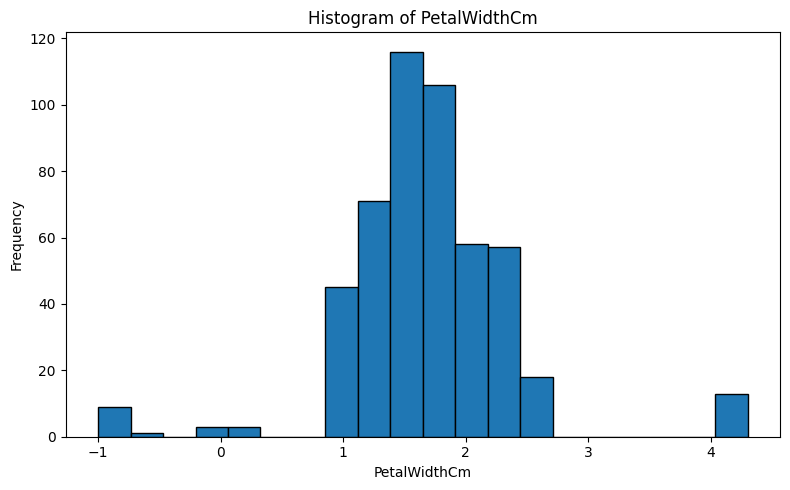

Feature with largest positive correlation with PetalWidthCm: PetalWidthCompactness (r=0.9917)

Top 5 features with strongest negative correlations with PetalWidthCm:
  SepalWidthMajorAxis: r=-0.0964
  SepalGlossIndex: r=-0.0952
  SepalWidthCompactness: r=-0.0885
  SepalWidthCurvature: r=-0.0813
  SepalWidthMinorAxis: r=-0.0744


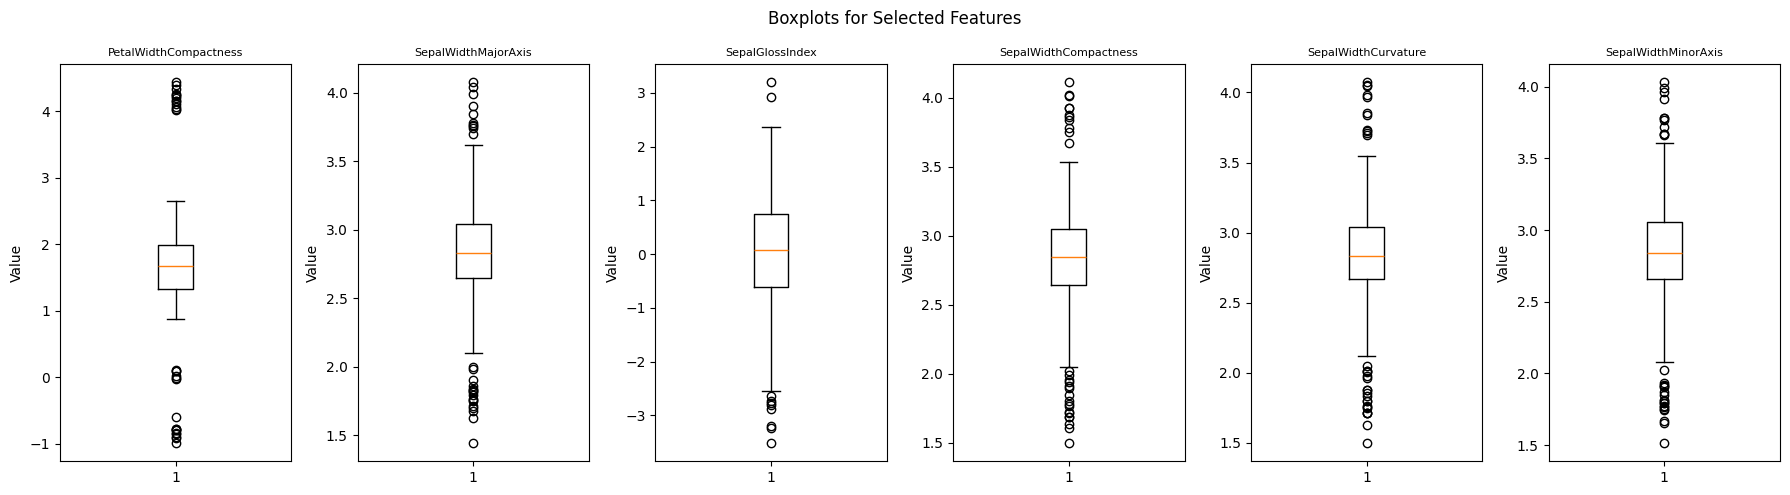

In [17]:
from sklearn.feature_selection import r_regression

# 4(a): Histogram of PetalWidthCm
plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=20, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4(b): Feature with largest positive Pearson correlation with PetalWidthCm
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
candidate_cols = [c for c in df.columns if c not in exclude_cols]
X_candidates = df[candidate_cols].values
y_target = df['PetalWidthCm'].values

correlations = r_regression(X_candidates, y_target)
corr_series = pd.Series(correlations, index=candidate_cols)

best_positive = corr_series.idxmax()
print(f"Feature with largest positive correlation with PetalWidthCm: {best_positive} (r={corr_series[best_positive]:.4f})")

# 4(c): Top 5 features with strongest negative correlations
neg_corr = corr_series[corr_series < 0].nsmallest(5)
print("\nTop 5 features with strongest negative correlations with PetalWidthCm:")
for feat, val in neg_corr.items():
    print(f"  {feat}: r={val:.4f}")

# 4(d): Boxplot for features from 4(b) and 4(c)
plot_features = [best_positive] + list(neg_corr.index)
fig, axes = plt.subplots(1, len(plot_features), figsize=(18, 5))
for ax, feat in zip(axes, plot_features):
    ax.boxplot(df[feat].dropna())
    ax.set_title(feat, fontsize=8)
    ax.set_ylabel('Value')
plt.suptitle('Boxplots for Selected Features')
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [18]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177568
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740429
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.573746996512145
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860384
750. Training loss: 0.49152377948438897, Val loss:0.56

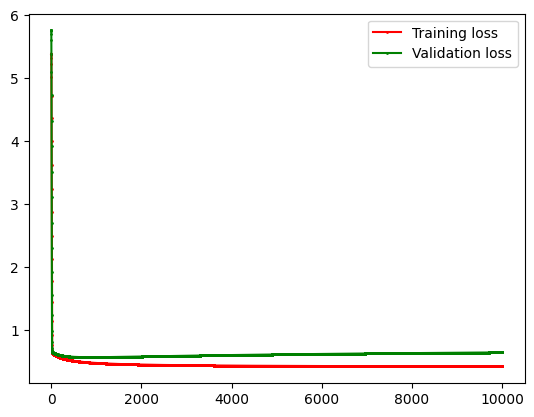

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

In [19]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


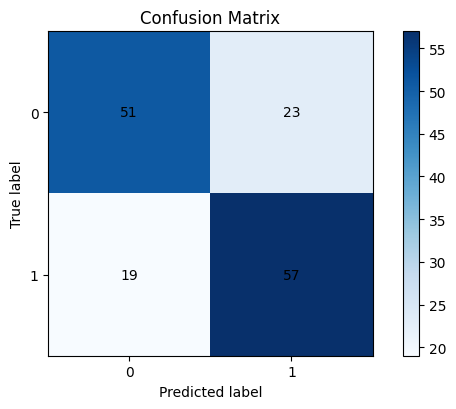

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [20]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

## Task 5: L2 Regularization


--- No Regularization ---
50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177568
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740429
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.573746996512145
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860384
750. Training loss: 0.49152

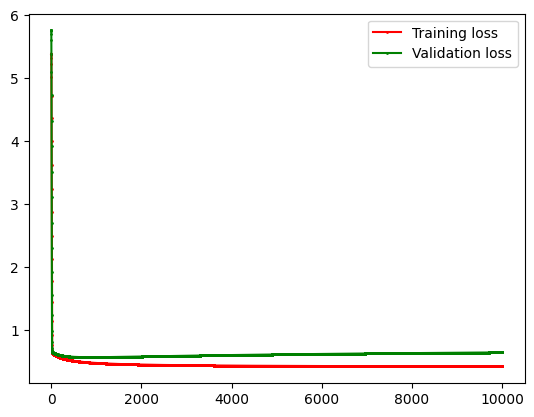


--- L2 reg_lambda=0.01 ---
50. Training loss: 0.6183968442308057, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.5636852669117252, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451082
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452545
550. Training loss: 0.5076902593666242, Val loss:0.5737553335810299
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402411
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888323
750. Training loss: 0

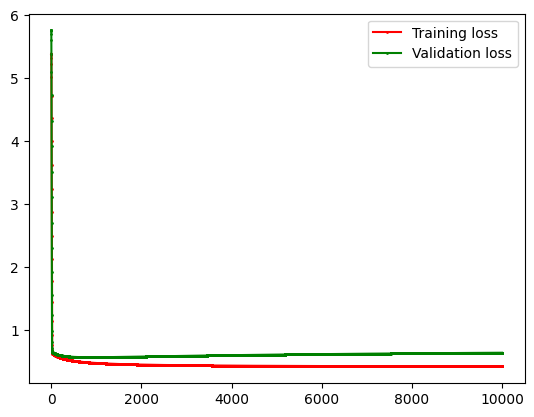


--- L2 reg_lambda=1 ---
50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.612622557656859
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908268
250. Training loss: 0.5571858255876307, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871134
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364933
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810414, Val loss:0.5758788683267104
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.5110797027848409, Val loss:0.5737215545999529
750. Training loss: 0.508656912

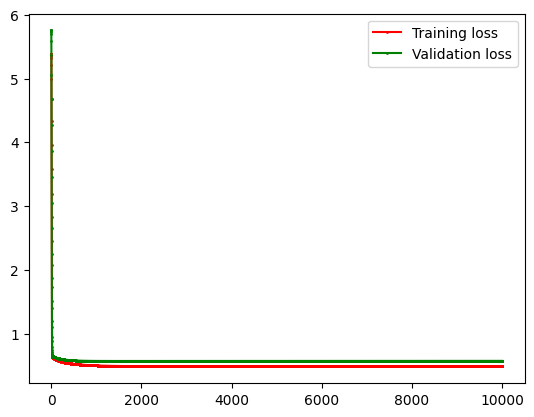


--- L2 reg_lambda=100 ---
50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460088
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.674

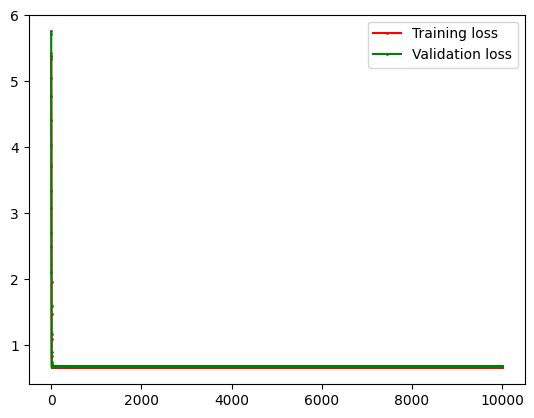

In [21]:
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

configs = [
    ('No Regularization', '', 0.0),
    ('L2 reg_lambda=0.01', 'l2', 0.01),
    ('L2 reg_lambda=1', 'l2', 1.0),
    ('L2 reg_lambda=100', 'l2', 100.0),
]

trained_models = {}
for label, reg_type, reg_lambda in configs:
    print(f"\n--- {label} ---")
    np.random.seed(seed)
    m = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    m.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type=reg_type, reg_lambda=reg_lambda)
    trained_models[label] = m

### 5(b): Evaluation on Test Set


=== No Regularization ===
No Regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


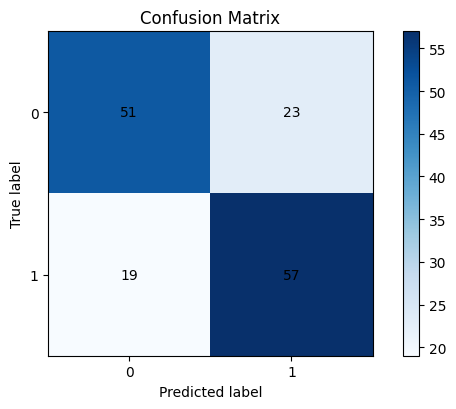


=== L2 reg_lambda=0.01 ===
L2 reg_lambda=0.01
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


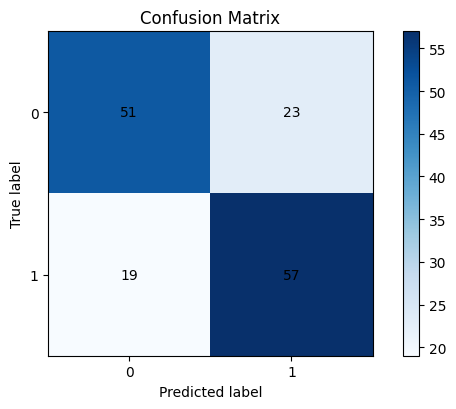


=== L2 reg_lambda=1 ===
L2 reg_lambda=1
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


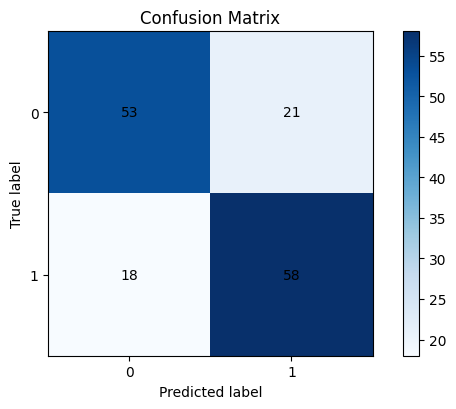


=== L2 reg_lambda=100 ===
L2 reg_lambda=100
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


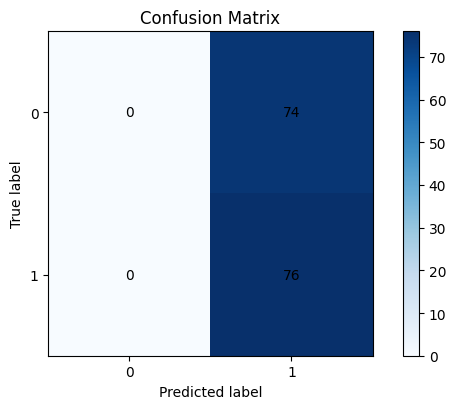

In [22]:
for label, model in trained_models.items():
    print(f"\n=== {label} ===")
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred, title=label)

## 3(b): Observations on KNN Imputation

**Before imputation** (columns with missing values):
| Column | Median | Std |
|---|---|---|
| SepalLengthCm | 6.3000 | 1.0371 |
| SepalWidthCm | 2.9000 | 0.3896 |
| PetalLengthCm | 5.0856 | 1.5828 |
| PetalWidthCm | 1.6000 | 0.7067 |
| BranchLength | 16.3000 | 1.0352 |

**After KNN imputation (k=5)**:
| Column | Median | Std |
|---|---|---|
| SepalLengthCm | 6.3000 | 1.0093 |
| SepalWidthCm | 2.9000 | 0.3724 |
| PetalLengthCm | 5.0357 | 1.5150 |
| PetalWidthCm | 1.7000 | 0.6946 |
| BranchLength | 16.3000 | 1.0110 |

The medians barely change - SepalLengthCm, SepalWidthCm, and BranchLength stay exactly the same, while PetalLengthCm and PetalWidthCm shift slightly. The standard deviations all decrease a little across the board. This makes sense: KNN fills missing values by averaging nearby neighbors, which pulls imputed values toward the local mean and never adds extreme values - so the spread naturally tightens. The fact that medians are stable means the missing data wasn't concentrated on one side of the distribution, so the central tendency is preserved.

## 4(a): Histogram Observations — PetalWidthCm

The histogram seems to show a normal distribution. However, with many outliers. There is a broad, normal-looking cluster spanning roughly 1.0–2.5 cm with a peak around 1.5–2.0 cm, indicating the mean. There are however many values at both ends, notably at 4 and -1, with -1 likely representing missing values considering the data is of a cm measurement.

## 5(c): Observations on L2 Regularization (5a & 5b)

**Training curves (5a):**

- **No regularization:** The training loss keeps decreasing throughout all 10000 iterations, but the validation loss bottoms out around iteration 900 (~0.569) and then slowly starts climbing. Classic overfitting — the model is memorizing training data while generalizing worse.

- **L2 lambda=0.01:** Nearly identical to no regularization. The curves are almost indistinguishable, the regularization term is too small relative to the loss to have any real effect.

- **L2 lambda=1:** The training loss is slightly higher than no regularization (constrained weights), but the validation loss is more stable and doesn't diverge upward as clearly. The model is better controlled.

- **L2 lambda=100:** The loss freezes after about 150 iterations at train=0.6747 / val=0.6839 and never moves again. The penalty term completely dominates the gradient — weights get crushed to near-zero and the model stops learning entirely.

**Test set evaluation (5b):**

| Setting | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| No regularization | 0.7200 | 0.7125 | 0.7500 | 0.7308 |
| L2 lambda=0.01 | 0.7200 | 0.7125 | 0.7500 | 0.7308 |
| L2 lambda=1 | **0.7400** | **0.7342** | **0.7632** | **0.7484** |
| L2 lambda=100 | 0.5067 | 0.5067 | 1.0000 | 0.6726 |

lambda=0.01 gives exactly the same result as no regularization — no practical difference. lambda=1 actually improves the test F1 from 0.7308 to 0.7484, confirming that moderate regularization helps generalization here. lambda=100 is completely broken: recall=1.0 and precision≈0.507 means the model is predicting every single sample as class 1 — the weights were driven so close to zero that only the bias term survives, which just always outputs the majority class.